In [14]:
from cardroom.briscola.game.env import BriscolaEnv
from cardroom.briscola.game.player import BriscolaPlayer
from cardroom.briscola.agents.random import RandomAgent
from cardroom.briscola.agents.bot import BotAgent
from cardroom.briscola.agents.donatello import DonatelloAgent
from cardroom.briscola.agents.evaluation.evaluate_agent import AgentEvaluator
from cardroom.briscola.agents.evaluation.evaluate_game import DeckMetricsEvaluator

from IPython.display import clear_output

Set up agent to be evaluated and run evalation

In [7]:
agent = DonatelloAgent(simulations = 200, rollout_policy = "random", cpuct = 1.4)

n_games = 500

Opponent: RandomAgent


Playing games... (Donatello wins: 452 | RandomAgent wins: 43 | Draws: 5): 100%|██████████| 500/500 [06:56<00:00,  1.20it/s]


Opponent: BotAgent


Playing games... (Donatello wins: 256 | BotAgent wins: 224 | Draws: 20): 100%|██████████| 500/500 [06:56<00:00,  1.20it/s]

=== Evaluation Recap ===
             wins  draws  losses  total_games  win_rate     EV       p_value  \
opponent                                                                       
RandomAgent   452      5      43          500     0.904  0.818  4.029896e-87   
BotAgent      256     20     224          500     0.512  0.064  1.570111e-01   

             significant  
opponent                  
RandomAgent         True  
BotAgent           False  
=== Flipped-side Analysis ===
             tot_pairs  won_both  lost_both  won_drew  lost_drew  one_each  \
opponent                                                                     
BotAgent           250        59         45        12          8       126   
RandomAgent        250       202          0         5          0        43   

             draw_draw  unknown  
opponent                         
BotAgent             0        0  
RandomAgent          0        0  


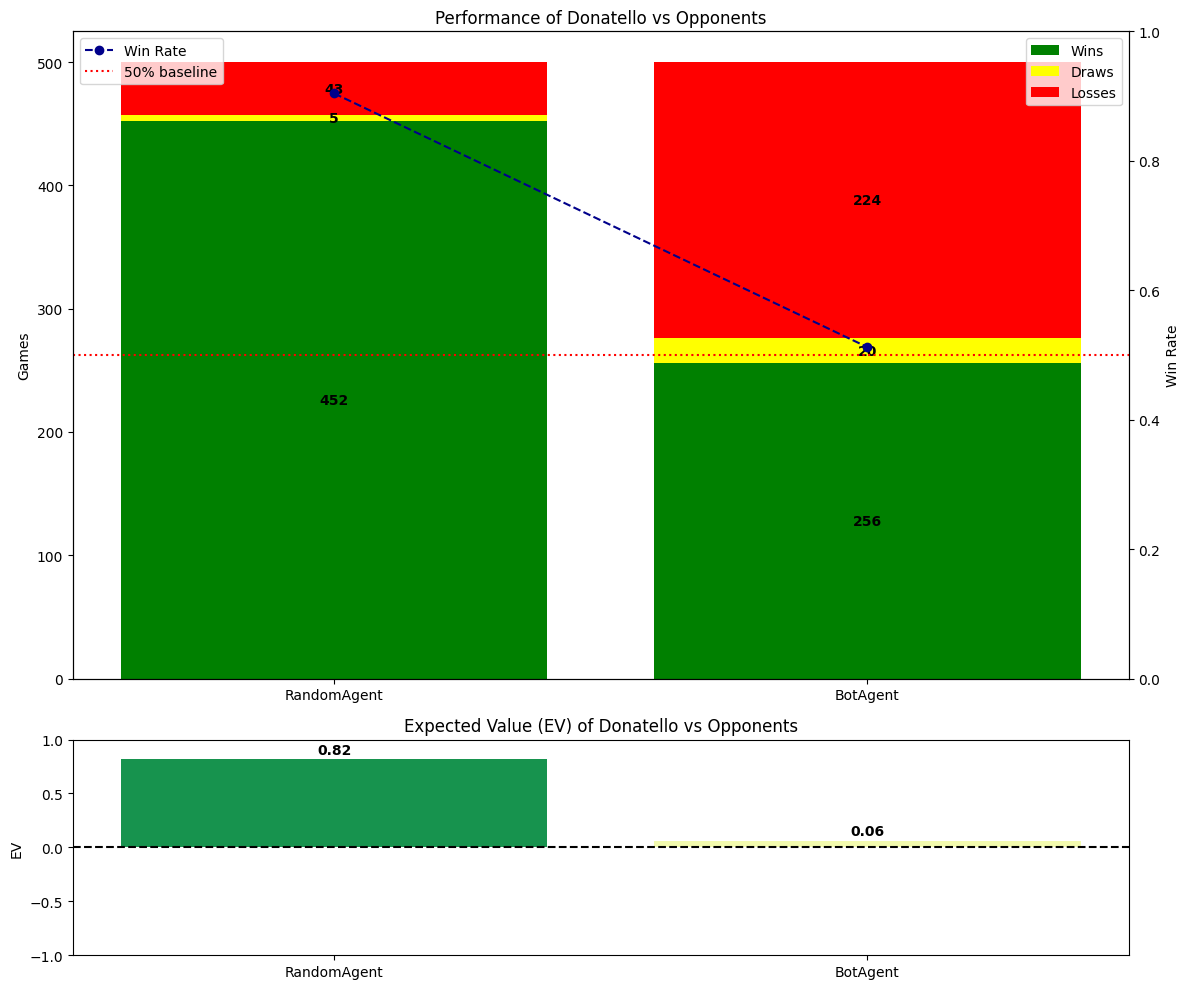

Evaluating endgames...


100%|██████████| 500/500 [00:17<00:00, 28.25it/s]


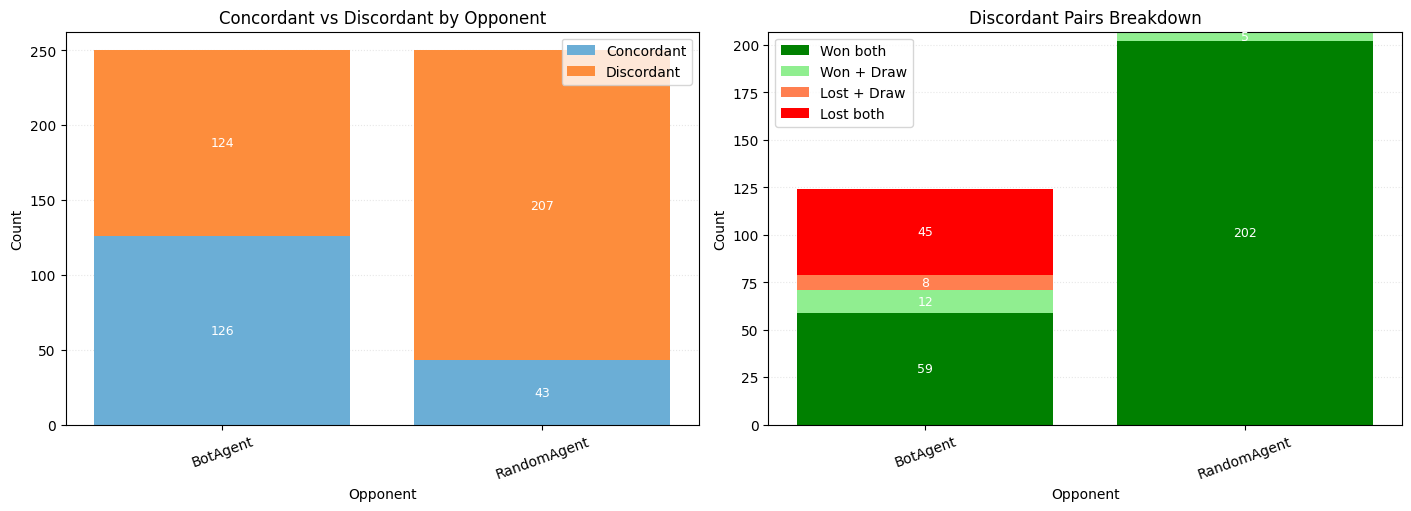

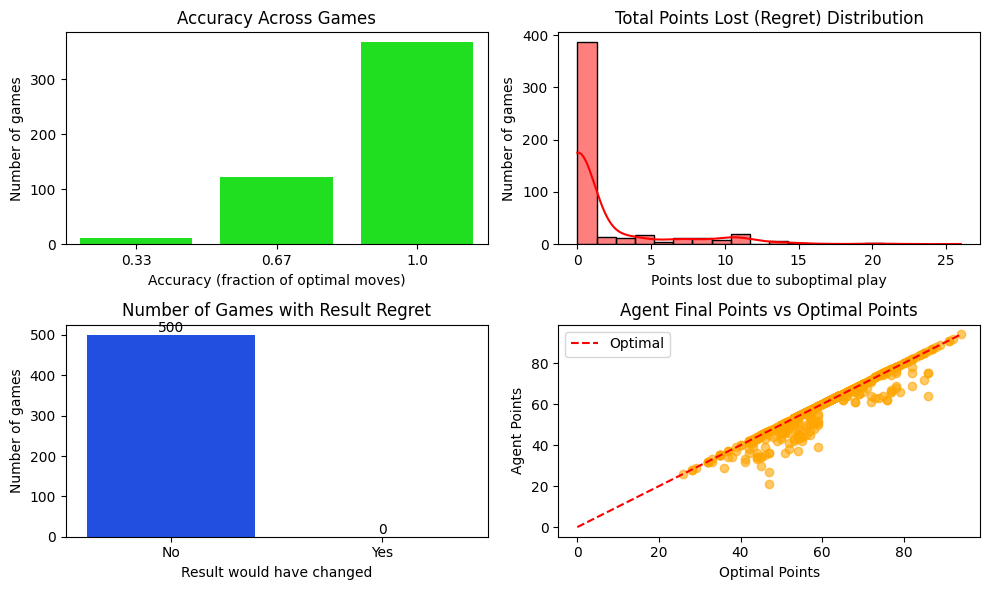

In [8]:
eval = AgentEvaluator(agent, n_games, opponents=[RandomAgent(), BotAgent()])
eval.run()

Analyze luck factor in the games

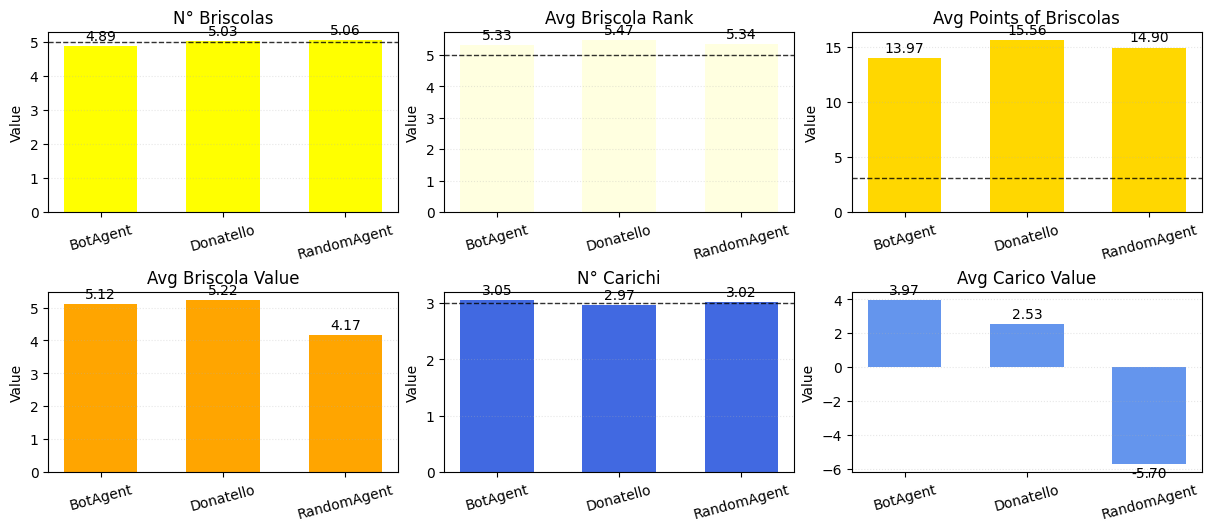

(        player  n_briscolas  avg_briscola_rank  briscola_points  \
 0     BotAgent        4.888           5.325107           13.970   
 1    Donatello        5.026           5.466125           15.565   
 2  RandomAgent        5.060           5.340095           14.900   
 
    avg_briscola_value  n_carichi  avg_carico_value  
 0            5.118181      3.050          3.969433  
 1            5.220621      2.966          2.532117  
 2            4.169167      3.018         -5.704433  ,
 <Figure size 1200x520 with 6 Axes>)

In [9]:
res = eval.results
res

states = []
for game in res["final_state"]:
    states.append(game)

deck = DeckMetricsEvaluator(states)

deck.run()

Game 646, pair 323; winner: BotAgent


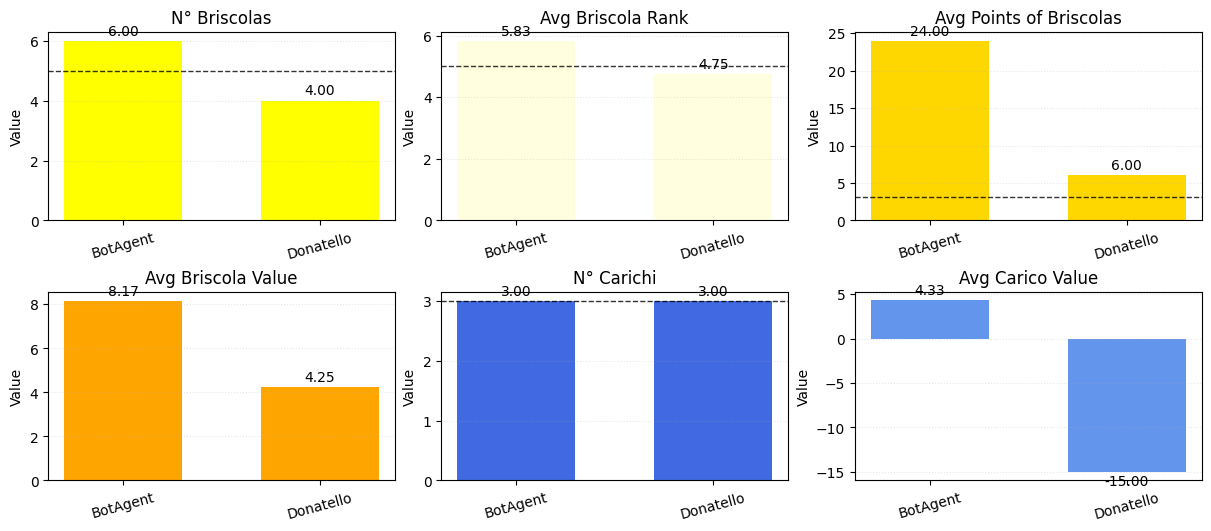

In [ ]:
opp = "BotAgent" # opponent to consider for analysis

for opponent, opp_rows in res.groupby("opponent"):
    if opponent != opp:
        continue
    for pair_id, g in opp_rows.groupby("pair_id"):
        if g["winner"].tolist() == [opp, opp]: # analyze pair where agent lost both games
            for game_idx, row in g.iterrows():
                print(f"Game {game_idx}, pair {row['pair_id']}; winner: {row['winner']}")
                deckeval = DeckMetricsEvaluator([row["final_state"]])
                deckeval.run()
                if input("Show next game? [y/n] ") == "n":
                    break
                else:
                    clear_output(wait=True)